# `cavity_analysis` Example Notebook

This notebook provides a practical introduction to the `cavity_analysis` class and demonstrates its main features through a typical workflow.

The examples presented here are intended to help you get started quickly. They are **not** an exhaustive overview of every feature or configuration supported by the class. Instead, they focus on the core functionality and the most common usage patterns, which should cover around **99% of everyday use cases**.

For more advanced applications or specialized configurations, please refer to the class documentation.

`cavity_analysis` is a Python class for fitting and analyzing resonant modes of cylindrical microwave cavities from experimental S-parameter data.

`cavity_analysis` takes measured data (complex transmission/reflection as a function of frequency and cavity length) and fits each resonant mode branch using a circle model in the complex plane. It then extracts physical parameters such as resonance frequency $f_0$ and total linewidth $\kappa_t$, and provides several visualization tools.

This class is designed to work alongside `cavity_theory`, which provides the theoretical mode predictions used as input to the fitting routine.

This class needs `analysis_functions.core` to work. To install this package and have more details about: https://gitlab.tudelft.nl/steelelab/steele-lab-analysis-functions.git

## Data used for this example notebook

Data used for this example jupyter notebook (SteeleLab NAS):
`steelelab/measurement_data/newBF/Pacome/Automatic_tuning/2026-07-01_09.47.44_0001_automatic_tuning/2026-07-01_09.47.44_0001_automatic_tuning__Cavity_map.h5`

Help on built-in function strftime:

strftime(...) method of datetime.datetime instance
    format -> strftime() style string.



Loading BokehJS ...

Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'length']
Removing edelay: -36.136235852746 * (2*pi*freq) + 2102.964882885599


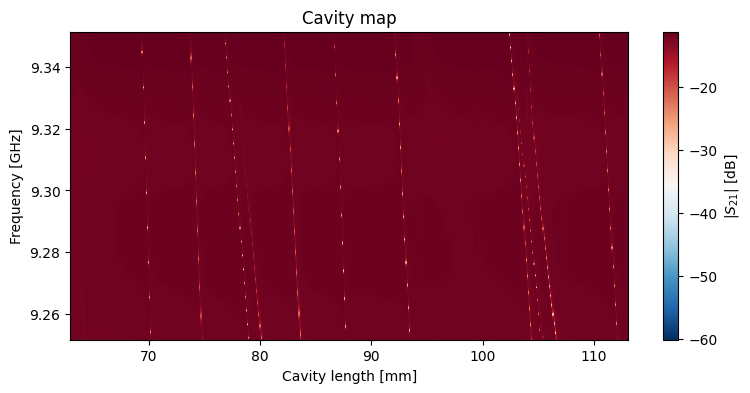

In [1]:
import glob
import xarray as xr
import dexplore as dx
import analysis_functions.core as af
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

data_path = "../../Example_Cavity_Map.h5"
h5_files = sorted(glob.glob(data_path))
data = xr.load_dataset(h5_files[0])

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9],
              'Cavity length (mm)': ['length', 'mm', 1]}

data = af.format_data_xarray(data, tool='VNA',translator=translator,remove_edelay=[0, 100, 0, 0])

fig, ax = plt.subplots(figsize=(9, 4))
data.mag.plot(ax=ax, cmap='RdBu_r')
ax.set_xlabel('Cavity length [mm]')
ax.set_ylabel('Frequency [GHz]')
ax.set_title('Cavity map')
plt.show()

## Initialization

Parameters of the initialization:

| Parameter | Type  | Description |
|---|---|---|
| `data` | `xarray.Dataset` | Experimental dataset containing cavity measurements.|
| `radius` | `float` | Cavity radius in millimeters. |

In [2]:
from microwave_cavity import cavity_analysis
from microwave_cavity import cavity_theory

analysis = cavity_analysis(
    data = data,
    radius = 25
)

thmodes = cavity_theory(
    radius = 25,            # Cavity radius in mm
    data = data             # Experimental data
)

thmodes.compute_modes()     # Compute theoretical modes

## Branche fit

One thing one wants to do is to fit branches of the map. To do so, `cavity_analysis` relies on `cavity_theory` to overlay the theory and the experimental data to identify where are the modes.

Parameters:

| Parameter | Type  | Description |
|---|---|---|
| `bandwidth` | `float` | Frequency window width in GHz used around each theoretical resonance.|
| `dict_modes` | `dict` | Dictionary of theoretical cavity modes, typically generated by `cavity_theory.compute_modes()`. |
| `mode_ids` | `list` | List of mode identifiers to fit. If not provided, all TE modes contained in `dict_modes` are fitted. TM cannot be fitted with this routine.|

First we plot the data with the theory. It helps to identify TEM modes, and to check if the overlay is good.

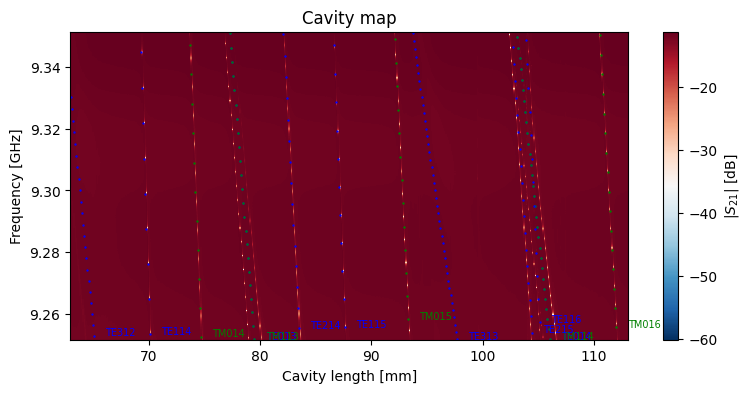

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
data.mag.plot(ax=ax, cmap='RdBu_r')
thmodes.plot_modes(colors = ['blue', 'green'], ax=ax, marker='.', s=2)
ax.set_xlabel('Cavity length [mm]')
ax.set_ylabel('Frequency [GHz]')
ax.set_title('Cavity map')
plt.show()

In [4]:
analysis.fit_branches(
    bandwidth = 50e-3,
    dict_modes = thmodes.dict_modes,
    mode_ids = ['TE114', 'TE115'])

The raw data of the fits are not diggest, so we have to 'clean' them. This is the only purpose of `compute_fit_results`. After this, we can plot the results of the fits.

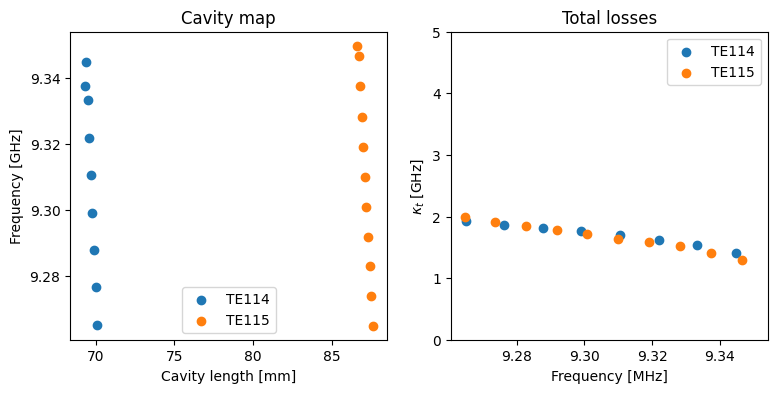

In [5]:
analysis.compute_fit_results()

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
analysis.plot_data_results(x='f0', y='kt', ax=ax[1])
ax[1].set_ylim(0, 5e-3)
ax[1].yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y * 1e3:.0f}"))
ax[1].set_xlabel('Frequency [MHz]')
ax[1].set_ylabel('$\kappa_t$ [GHz]')
ax[1].legend()
ax[1].set_title('Total losses')

analysis.plot_data_results(x='length', y='f0', ax=ax[0])
ax[0].set_xlabel('Cavity length [mm]')
ax[0].set_ylabel('Frequency [GHz]')
ax[0].legend()
ax[0].set_title('Cavity map')
plt.show()

If the results fromt the fits are bad, you can check the data fitted by plotting the mask defined by `bandwidth`.

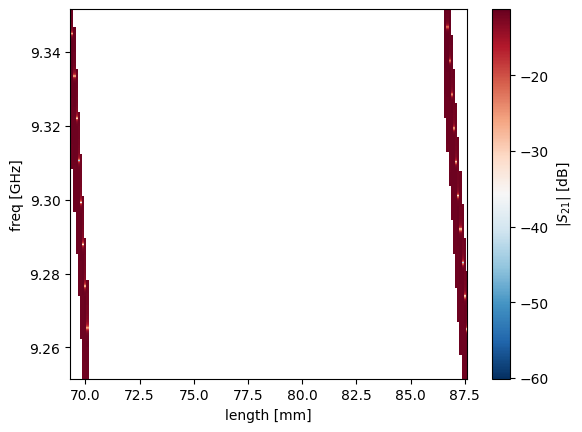

In [6]:
analysis.plot_masked_branches()

## Other features

`linear_fit_modes` is a function to do a linear fit of each branche, and saves the results in a dictionary. The purpose of this function is to be used during the automatic tuning of the cavity filter. Otherwise, this function is useless for everyday usage.